In [2]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os

### Pluviómetro - Cauce Rambla Albujón

In [3]:
path = "Ramblas/"
# Diccionario para almacenar los dataframes
dataframes = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Pluviometro.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}_pluviometro"
                # Almacenar el dataframe en el diccionario
                dataframes[nombre_df] = df

pluvios_to_keep = ["Desemboc Rbla Albujon_pluviometro", "La Puebla_pluviometro", "Pozo Estrecho_pluviometro", "Rbla Albujon_pluviometro", "El Estrecho_pluviometro", "Fuente Alamo_pluviometro", "Los Cegarras_pluviometro"]
dataframes = {key: df for key, df in dataframes.items() if key in pluvios_to_keep}

# Dataframe vacío
combined_df = pd.DataFrame()

# Iterar sobre cada dataframe filtrado
for location, df in dataframes.items():
    df = df.set_index("Date")
    df = df.rename(columns={"Pluviometro": location})

    if combined_df.empty:
        combined_df = df
    else:
        combined_df = combined_df.join(df, how="outer")

combined_df = combined_df.reset_index()
# Convertir la columna 'Date' al formato datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
# Ponemos la fecha como índice
combined_df = combined_df.set_index('Date')
# Reemplazamos las '-' con NaN
combined_df.replace('-', np.nan, inplace=True)
# Reemplazamos NaN por 0's
combined_df.fillna(0, inplace=True)
# Ponemos como float los valores de los pluvios
combined_df = combined_df.astype({col: 'float' for col in combined_df.columns})
# Agrupamos los datos por día, sumando la precipitación acumulada
df_pluvio = combined_df.resample('D').sum()
# Definimos una columna que sea la suma de todos los pluvios
df_pluvio['Total'] = df_pluvio.loc[:, df_pluvio.columns].sum(axis=1)
df_pluvio = df_pluvio.reset_index()

In [3]:
df_pluvio.head(3)

,Date,El Estrecho_pluviometro,Los Cegarras_pluviometro,Pozo Estrecho_pluviometro,Rbla Albujon_pluviometro,La Puebla_pluviometro,Fuente Alamo_pluviometro,Desemboc Rbla Albujon_pluviometro,Total
0,2016-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2016-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Caudal - Desembocadura

In [36]:
path = "Ramblas/"
dataframes = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Caudal.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}_caudal"
                # Almacenar el dataframe en el diccionario
                dataframes[nombre_df] = df

caudal_to_keep = ["Desemboc Rbla Albujon_caudal"]
dataframes = {key: df for key, df in dataframes.items() if key in caudal_to_keep}

# Dataframe vacío
combined_df = pd.DataFrame()

# Iterar sobre cada dataframe filtrado
for location, df in dataframes.items():
    df = df.set_index("Date")
    df = df.rename(columns={"Caudal": location})

    if combined_df.empty:
        combined_df = df
    else:
        combined_df = combined_df.join(df, how="outer")

combined_df = combined_df.reset_index()
# Convertir la columna 'Date' al formato datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
# Ponemos la fecha como índice
combined_df = combined_df.set_index('Date')
# Reemplazamos las '-' con NaN
#combined_df.replace('-', np.nan, inplace=True)
combined_df.replace(['-', 'null', 'NULL', 'None', ''], np.nan, inplace=True)
# Reemplazamos NaN por 0's
combined_df.fillna(0, inplace=True)
# Ponemos como float los valores de los pluvios
combined_df = combined_df.astype({col: 'float' for col in combined_df.columns})
# Agrupamos los datos por día, sumando la precipitación acumulada
df_caudal = combined_df.resample('D').mean()*1000 # *1000 Para estar en l/s
# Definimos una columna que sea la suma de todos los pluvios
df_caudal['Total'] = df_caudal.loc[:, df_caudal.columns].sum(axis=1)
df_caudal = df_caudal.reset_index()

In [37]:
df_caudal.head(3)

,Date,Desemboc Rbla Albujon_caudal,Total
0,2021-01-12,184.312500,184.312500
1,2021-01-13,184.152778,184.152778
2,2021-01-14,177.222222,177.222222


### Nitratos/Fosfatos y Caudal Canal Mar Menor

In [15]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "Registro_Ramblas_MARMENOR.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
    # "Conductividad": range(1, 25),
    # "NitratosDiario": range(1, 14),
    # "FosfatosDiario": range(1, 14)
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}

# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia", "Rambla de las Matildes - corriente sur", "Lo Poyo"]

for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]


df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Nitratos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner')
df_nitratos_diario = pd.DataFrame(index=aligned_df1.index)

for col in aligned_df1.columns:
    df_nitratos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6

dataframes['Nitratos Diario'] = df_nitratos_diario.reset_index()


df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Fosfatos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner')
df_fosfatos_diario = pd.DataFrame(index=aligned_df1.index)

for col in aligned_df1.columns:
    df_fosfatos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6

dataframes['Fosfatos Diario'] = df_fosfatos_diario.reset_index()

In [5]:
dataframes["Nitratos Diario"]['Nitratos CTD7'] = dataframes["Nitratos Diario"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes["Fosfatos Diario"]['Fosfatos CTD7'] = dataframes["Fosfatos Diario"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes["Nitratos"]['Nitratos CTD7'] = dataframes["Nitratos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes["Fosfatos"]['Fosfatos CTD7'] = dataframes["Fosfatos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)

dataframes["Caudal"]["Caudal CTD7"] = dataframes["Caudal"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)

# dataframes["Nitratos Diario"]['Nitratos CTD9'] = dataframes["Nitratos Diario"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
# dataframes["Fosfatos Diario"]['Fosfatos CTD9'] = dataframes["Fosfatos Diario"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
# dataframes["Nitratos"]['Nitratos CTD9'] = dataframes["Nitratos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
# dataframes["Fosfatos"]['Fosfatos CTD9'] = dataframes["Fosfatos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)

In [7]:
dataframes["Nitratos Diario"].head(3)

,Fecha,Desembocadura rambla Albujón,Obra de paso bajo carretera Los Urrutia,Rambla de las Matildes - corriente sur,Lo Poyo,Nitratos CTD7
0,2019-08-30,0.0,0.0,0.0,0.0,0.0
1,2019-09-06,0.0,0.0,0.0,0.0,0.0
2,2019-09-20,0.0,0.0,0.0,0.0,0.0


In [11]:
dataframes["Caudal"].head(3)

,Fecha,Desembocadura rambla Albujón,Obra de paso bajo carretera Los Urrutia,Rambla de las Matildes - corriente sur,Lo Poyo,Caudal CTD7
1,2019-08-30,0.0,0.0,0.0,0.0,0.0
2,2019-09-06,0.0,0.0,0.0,0.0,0.0
3,2019-09-20,0.0,0.0,0.0,0.0,0.0


### Nitratos/Fosfatos y Caudal SAIH

In [ ]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "Registro_Ramblas_MARMENOR.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
    # "Conductividad": range(1, 25),
    # "NitratosDiario": range(1, 14),
    # "FosfatosDiario": range(1, 14)
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}

# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón"]

for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]

df1 = df_caudal.set_index('Date')
df2 = dataframes['Nitratos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner', axis=0)
df_nitratos_diario = pd.DataFrame(index=aligned_df1.index)

df_nitratos_diario["Desembocadura Rambla Albujón"] = aligned_df1["Total"] * aligned_df2["Desembocadura rambla Albujón"] * 86400/1e6


dataframes['Nitratos Diario'] = df_nitratos_diario.reset_index()
df1 = df_caudal.set_index('Date')
df2 = dataframes['Fosfatos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner', axis=0)
df_fosfatos_diario = pd.DataFrame(index=aligned_df1.index)

df_fosfatos_diario["Desembocadura Rambla Albujón"] = aligned_df1["Total"] * aligned_df2["Desembocadura rambla Albujón"] * 86400/1e6

dataframes['Fosfatos Diario'] = df_fosfatos_diario.reset_index()

### Temperatura, Clorofila y Oxígeno CTD7

In [6]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD7"] #[f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

dataframes_boya_CTD7 = {k: v for k, v in dataframes_boyas.items() if "CTD7" in k}

### Plots

In [7]:
series1 = df_pluvio.set_index("Date")["Total"]
pluvio_scaled = np.log1p(series1)#pd.Series(scaler1.fit_transform(series1.values.reshape(-1, 1)).flatten(), index=series1.index, name=series1.name)

series2 = dataframes["Nitratos Diario"].set_index("Fecha")['Nitratos CTD7']
nitratos_scaled = np.log1p(series2)

series3 = dataframes["Caudal"].set_index("Fecha")['Caudal CTD7']
caudal_scaled = np.log1p(series3)

dataframes_boya_CTD7["CTD7_Temperatura"]["Date"] = pd.to_datetime(dataframes_boya_CTD7["CTD7_Temperatura"]["Date"])
series4 = dataframes_boya_CTD7["CTD7_Temperatura"].set_index("Date")['0.5']
temperatura_scaled = np.log1p(series4)**2

dataframes_boya_CTD7["CTD7_Clorofila"]["Date"] = pd.to_datetime(dataframes_boya_CTD7["CTD7_Clorofila"]["Date"])
series5 = dataframes_boya_CTD7["CTD7_Clorofila"].set_index("Date")['0.5']
clorofila_scaled = np.log1p(series5)
clorofila_scaled = series5*2

dataframes_boya_CTD7["CTD7_Oxigeno"]["Date"] = pd.to_datetime(dataframes_boya_CTD7["CTD7_Oxigeno"]["Date"])
series6 = dataframes_boya_CTD7["CTD7_Oxigeno"].set_index("Date")['0.5']
oxigeno_scaled = series6#np.log1p(series6)

series7 = dataframes["Fosfatos Diario"].set_index("Fecha")['Fosfatos CTD7']
fosfatos_scaled = np.log1p(series7)*2

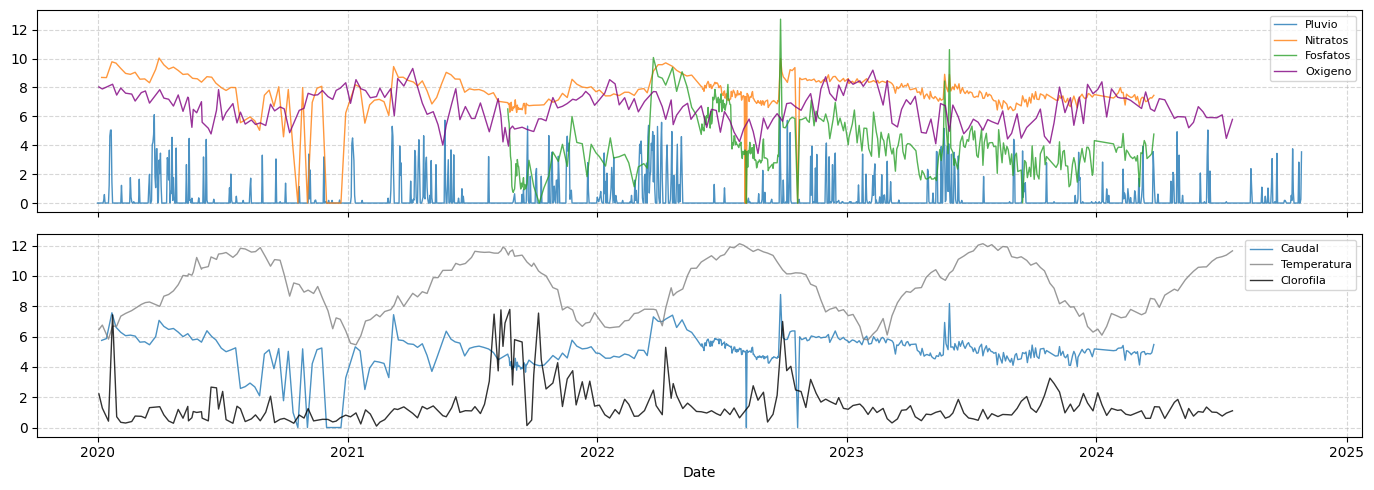

In [9]:
fig, ax = plt.subplots(figsize=(14, 5), nrows=2, ncols=1, sharex=True)

start_date = '2020-01-01'
pluvio_scaled = pluvio_scaled[pluvio_scaled.index >= start_date]
nitratos_scaled = nitratos_scaled[nitratos_scaled.index >= start_date]
fosfatos_scaled = fosfatos_scaled[fosfatos_scaled.index >= start_date]
caudal_scaled = caudal_scaled[caudal_scaled.index >= start_date]
temperatura_scaled = temperatura_scaled[temperatura_scaled.index >= start_date]
clorofila_scaled = clorofila_scaled[clorofila_scaled.index >= start_date]
oxigeno_scaled = oxigeno_scaled[oxigeno_scaled.index >= start_date]

ax[0].plot(pluvio_scaled.index, pluvio_scaled, label=f'Pluvio', linewidth=1, alpha = 0.8)
ax[0].plot(nitratos_scaled.index, nitratos_scaled, label=f'Nitratos', linewidth=1, alpha = 0.8)
ax[0].plot(fosfatos_scaled.index, fosfatos_scaled, label=f'Fosfatos', linewidth=1, alpha = 0.8)
ax[1].plot(caudal_scaled.index, caudal_scaled, label=f'Caudal', linewidth=1, alpha = 0.8)
ax[1].plot(temperatura_scaled.index, temperatura_scaled, label=f'Temperatura', linewidth=1, alpha = 0.8, color = "grey")
ax[1].plot(clorofila_scaled.index, clorofila_scaled, label=f'Clorofila', linewidth=1, alpha = 0.8, color="black")
ax[0].plot(oxigeno_scaled.index, oxigeno_scaled, label=f'Oxigeno', linewidth=1, alpha = 0.8, color="purple")

ax[0].set_title("")
ax[1].set_xlabel('Date')
ax[0].legend(loc='upper right', fontsize=8)
ax[1].legend(loc='upper right', fontsize=8)
ax[0].grid(True, linestyle = '--', alpha = 0.5)
ax[1].grid(True, linestyle = '--', alpha = 0.5)


fig.tight_layout()